Block 1 - Load data and explore FICO score distribution

same dataset as task 3 (Loan_Data.csv)

we want to understand:

- what range FICO scores cover
- how defaults are distributed across FICO scores
- lower FICO = higher default risk

(10000, 8)


,fico_score,default
count,10000.000000,10000.000000
mean,637.557700,0.185100
std,60.657906,0.388398
min,408.000000,0.000000
25%,597.000000,0.000000
50%,638.000000,0.000000
75%,679.000000,0.000000
max,850.000000,1.000000



FICO min:  408

FICO max:  850

Default rate by FICO band
fico_band
(407.558, 452.2]    0.583
(452.2, 496.4]      0.735
(496.4, 540.6]      0.510
(540.6, 584.8]      0.354
(584.8, 629.0]      0.205
(629.0, 673.2]      0.133
(673.2, 717.4]      0.079
(717.4, 761.6]      0.036
(761.6, 805.8]      0.019
(805.8, 850.0]      0.042
Name: default, dtype: float64


/var/folders/hc/0hj953jj47b5k0cwy0lp1vqr0000gn/T/ipykernel_42757/2820439512.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_band = df.groupby('fico_band')['default'].mean().round(3)       # takes mean of default column in each FICO interval


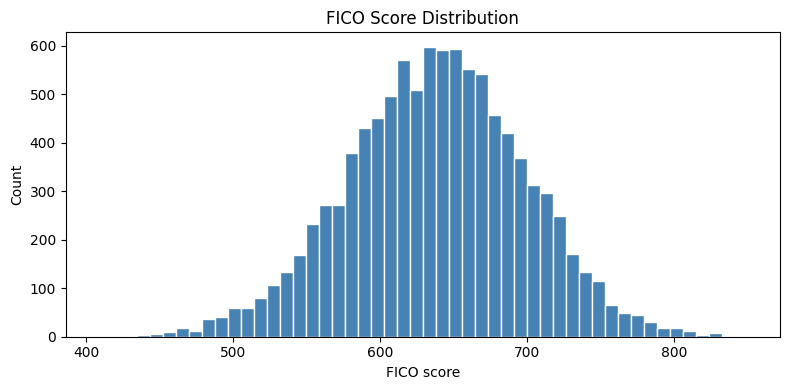

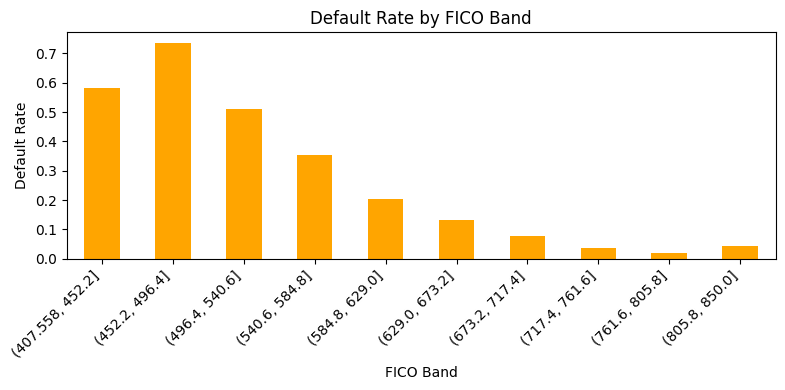

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

print(df.shape)
display(df[['fico_score', 'default']].describe())

print("\nFICO min: ", df['fico_score'].min())
print("\nFICO max: ", df['fico_score'].max())

df['fico_band'] = pd.cut(df['fico_score'], bins = 10)       # divides fico score to 10 equal intervals
default_by_band = df.groupby('fico_band')['default'].mean().round(3)       # takes mean of default column in each FICO interval
print("\nDefault rate by FICO band")
print(default_by_band)

# plot FICO score distribution
plt.figure(figsize=(8,4))
plt.hist(df['fico_score'], bins = 50, color = 'steelblue', edgecolor = 'white')
plt.xlabel('FICO score')
plt.ylabel('Count')
plt.title('FICO Score Distribution')
plt.tight_layout()
plt.savefig('fico_distribution.png', dpi=150)
plt.show()

# plot default rate by FICO band
# should show higher FICO = lower default rate
plt.figure(figsize=(8,4))
default_by_band.plot(kind = 'bar', color = 'orange')
plt.xlabel('FICO Band')
plt.ylabel('Default Rate')
plt.title('Default Rate by FICO Band')
plt.xticks(rotation=45, ha='right')     #  ha = horizontal alignment - rotate x-axis labels and align them to the right for better readability
plt.tight_layout()
plt.savefig('default_rate_by_fico.png', dpi=150)
plt.show()


Block 2 - log likelihood function for a single bucket

for any group of borrowers in a bucket:

    n = total borrowers

    k = number who defaulted

    p = k / n  ->  default rate in this bucket

log-likelihood = k * log(p) + (n-k) * log(1-p)

measures how "pure" and informative a bucket is

less negative = better bucket

we want to maximise the total across all buckets

In [4]:
df_sorted = df.sort_values('fico_score').reset_index(drop=True)

# 10,000 borrowers makes O(n²) precomputation too slow
# sample 1000 -> still representative, runs in seconds
df_sample = df_sorted.sample(n=1000, random_state=42).sort_values('fico_score').reset_index(drop=True)

defaults = df_sample['default'].values
fico = df_sample['fico_score'].values

print(f"Using {len(defaults)} borrowers for DP")
print(f"FICO range: {fico.min()} to {fico.max()}")

def bucket_log_likelihood(start_idx, end_idx):
    """
    computes log-likelihood for one bucket covering index range [start_idx, end_idx)

    start_idx : first borrower index in this bucket (inclusive)
    end_idx   : last borrower index in this bucket (exclusive)
    """

    bucket = defaults[start_idx : end_idx]

    n = len(bucket)
    k = int(bucket.sum())       # number of defaulters

    # if everyone defaults or no one defaults -> log(0) is undefined. this bucket contributes nothing useful
    if k == 0 or k == n:
        return 0
    
    p = k/n     # default rate

    ll = k * np.log(p) + (n - k) * np.log(1 - p)        # log likelihood formula

    return ll

# test 1 - entire dataset as 1 bucket (no splits)

ll_one_bucket = bucket_log_likelihood(0, len(defaults))
print(f"Log Likelihood, 1 bucket (no split): {ll_one_bucket: .2f}")

# test 2 - split into two halves

mid = len(defaults) // 2
ll_two_buckets = bucket_log_likelihood(0, mid) + bucket_log_likelihood(mid, len(defaults))
print(f"Log Likelihood, 2 bucket: {ll_two_buckets: .2f}")

print(f"\nImprovement from splitting: {ll_two_buckets - ll_one_bucket:.2f}")
print("(should be positive -> splitting always helps or stays the same)")

Using 1000 borrowers for DP
FICO range: 408 to 826
Log Likelihood, 1 bucket (no split): -484.77
Log Likelihood, 2 bucket: -447.06

Improvement from splitting: 37.71
(should be positive -> splitting always helps or stays the same)


Block 3 - Dynamic Programming to find optimal bucket boundaries

goal - find k-1 boundary points that maximise log likelihood

approach: 

- precompute log likelihood for every possible sub-range [i,j]
- use DP to build up optimal solution for k buckets
- dp[k][i] = best total log likelihood using k buckets covering borrowers 0-i


In [5]:
# ── BLOCK 3: Dynamic Programming — Optimal FICO Buckets ───────────────────────

def find_optimal_buckets(n_buckets):
    """
    finds optimal FICO score bucket boundaries using dynamic programming

    n_buckets : how many buckets you want (e.g. 5)

    returns: list of FICO score boundaries and default rate per bucket
    """

    n = len(defaults)   # total number of borrowers

    # ── step 1: precompute log-likelihood for every possible sub-range ─────────
    # ll_matrix[i][j] = log-likelihood if borrowers i to j form one bucket
    # this is expensive to compute on the fly inside DP, so we do it once here

    ll_matrix = {}
    for i in range(n):
        for j in range(i + 1, n + 1):
            ll_matrix[(i, j)] = bucket_log_likelihood(i, j)

    # ── step 2: DP table ───────────────────────────────────────────────────────
    # dp[k][i] = best total log-likelihood using exactly k buckets
    #            covering borrowers from index 0 to i
    # split[k][i] = where the last bucket started (to reconstruct boundaries later)

    dp = {}
    split = {}

    # base case: 1 bucket covering borrowers 0 to i
    for i in range(1, n + 1):
        dp[(1, i)] = ll_matrix[(0, i)]
        split[(1, i)] = 0

    # fill in for k = 2, 3, ..., n_buckets
    for k in range(2, n_buckets + 1):
        for i in range(k, n + 1):

            best_ll = -np.inf   # start with worst possible value
            best_split = -1

            # try every possible start point for the last bucket
            # last bucket goes from j to i, previous k-1 buckets cover 0 to j
            for j in range(k - 1, i):
                ll = dp.get((k - 1, j), -np.inf) + ll_matrix[(j, i)]

                if ll > best_ll:
                    best_ll = ll
                    best_split = j

            dp[(k, i)] = best_ll
            split[(k, i)] = best_split

    # ── step 3: reconstruct bucket boundaries from split table ─────────────────
    boundaries_idx = []   # boundary positions as indices into sorted array
    i = n
    k = n_buckets

    while k > 0:
        j = split[(k, i)]
        boundaries_idx.append(j)
        i = j
        k -= 1

    boundaries_idx.reverse()   # we built it backwards, so flip it

    # convert index boundaries to actual FICO score values
    fico_boundaries = [fico[idx] for idx in boundaries_idx[1:]]  # skip the 0 index (start)

    # ── step 4: print results ──────────────────────────────────────────────────
    print(f"\nOptimal boundaries for {n_buckets} buckets:")
    print(f"FICO boundaries: {fico_boundaries}")

    print(f"\nBucket details:")
    prev_idx = 0
    for b, boundary_idx in enumerate(boundaries_idx[1:] + [n]):
        bucket = defaults[prev_idx:boundary_idx]
        n_borrowers = len(bucket)
        n_defaults = int(bucket.sum())
        default_rate = n_defaults / n_borrowers if n_borrowers > 0 else 0
        fico_min = fico[prev_idx]
        fico_max = fico[boundary_idx - 1]

        print(f"  Bucket {b+1}: FICO {fico_min}-{fico_max} | "
              f"borrowers={n_borrowers} | "
              f"defaults={n_defaults} | "
              f"default rate={default_rate:.1%}")
        prev_idx = boundary_idx

    print(f"\nTotal log-likelihood: {dp[(n_buckets, n)]:.2f}")
    print(f"vs 1 bucket baseline: {ll_matrix[(0, n)]:.2f}")
    print(f"Improvement: {dp[(n_buckets, n)] - ll_matrix[(0, n)]:.2f}")

    return fico_boundaries

# run with 5 buckets
boundaries = find_optimal_buckets(5)


Optimal boundaries for 5 buckets:
FICO boundaries: [np.int64(515), np.int64(567), np.int64(645), np.int64(696)]

Bucket details:
  Bucket 1: FICO 408-515 | borrowers=31 | defaults=24 | default rate=77.4%
  Bucket 2: FICO 515-567 | borrowers=105 | defaults=44 | default rate=41.9%
  Bucket 3: FICO 567-644 | borrowers=392 | defaults=85 | default rate=21.7%
  Bucket 4: FICO 645-696 | borrowers=312 | defaults=32 | default rate=10.3%
  Bucket 5: FICO 696-826 | borrowers=160 | defaults=4 | default rate=2.5%

Total log-likelihood: -414.80
vs 1 bucket baseline: -484.77
Improvement: 69.97


Block 4 — visualise optimal bucket boundaries on FICO distribution

plot the FICO histogram with vertical lines showing where the DP

placed the bucket boundaries, and annotate each bucket's default rate

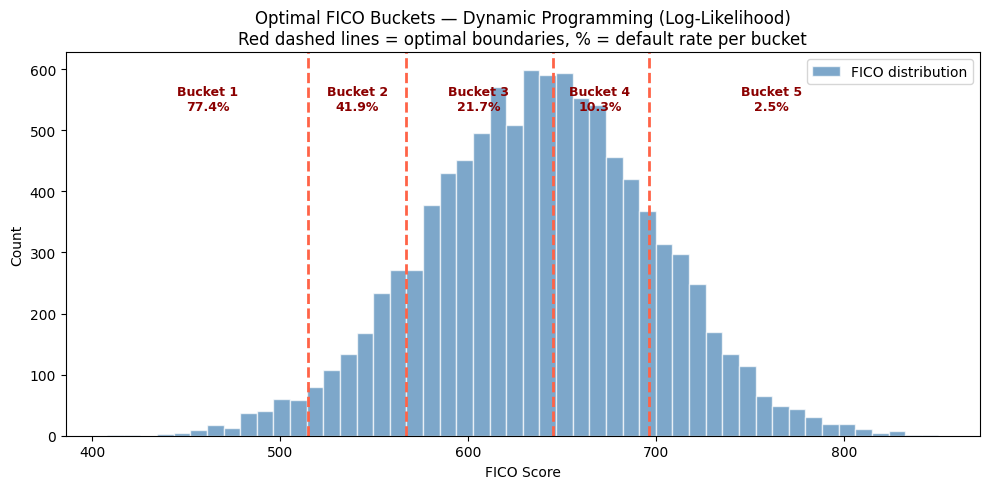

Rating Map (lower rating = better credit score):
  Rating 1 (highest risk): FICO 408  - 515  | default rate 77.4%
  Rating 2               : FICO 515  - 567  | default rate 41.9%
  Rating 3               : FICO 567  - 644  | default rate 21.7%
  Rating 4               : FICO 644  - 696  | default rate 10.3%
  Rating 5 (lowest risk) : FICO 696  - 826  | default rate  2.5%


In [6]:
# ── BLOCK 4: Visualise Optimal Buckets ────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# plot full FICO distribution (all 10,000 borrowers, not just the sample)
ax.hist(df_sorted['fico_score'], bins=50, color='steelblue',
        edgecolor='white', alpha=0.7, label='FICO distribution')

# draw vertical lines at each boundary the DP found
for b in boundaries:
    ax.axvline(x=b, color='tomato', linewidth=2, linestyle='--')

# annotate each bucket with its default rate
bucket_info = [
    (408, 515, "77.4%"),
    (515, 567, "41.9%"),
    (567, 644, "21.7%"),
    (644, 696, "10.3%"),
    (696, 826, "2.5%")
]

for i, (start, end, rate) in enumerate(bucket_info):
    mid = (start + end) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.85, f'Bucket {i+1}\n{rate}',
            ha='center', fontsize=9, color='darkred', fontweight='bold')

ax.set_xlabel('FICO Score')
ax.set_ylabel('Count')
ax.set_title('Optimal FICO Buckets — Dynamic Programming (Log-Likelihood)\n'
             'Red dashed lines = optimal boundaries, % = default rate per bucket')
ax.legend()
plt.tight_layout()
plt.savefig('fico_buckets.png', dpi=150)
plt.show()

# print the rating map -> lower rating = better credit
print("Rating Map (lower rating = better credit score):")
print(f"  Rating 1 (highest risk): FICO 408  - 515  | default rate 77.4%")
print(f"  Rating 2               : FICO 515  - 567  | default rate 41.9%")
print(f"  Rating 3               : FICO 567  - 644  | default rate 21.7%")
print(f"  Rating 4               : FICO 644  - 696  | default rate 10.3%")
print(f"  Rating 5 (lowest risk) : FICO 696  - 826  | default rate  2.5%")